# TT-18 — 01. Data Cleaning & Feature Preparation
### Ames Housing — Thẩm định giá nhà tự động (AVM)

## 0. Import & đường dẫn

In [9]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from features import (
    load_and_clean, add_engineered_features, build_feature_pipeline,
    FeatureEncoder, NONE_COLS, ZERO_COLS, QUAL_COLS, QUAL_ORDER
)

DATA_PATH = '../dataset/train.csv'

## 1. Load dữ liệu & thống kê giá trị thiếu

`load_and_clean` sẽ tự in ra số cột "thiếu vì không có tiện ích" so với
số cột "thiếu thật" — nhưng ở đây ta xem chi tiết từng cột trước khi xử lý,
để hiểu rõ *tại sao* lại phân loại như vậy.

In [10]:
df_raw = pd.read_csv(DATA_PATH)
print('Kích thước dữ liệu gốc:', df_raw.shape)

missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nSố cột có giá trị thiếu: {len(missing)}')
missing.to_frame('so_luong_thieu')

Kích thước dữ liệu gốc: (1460, 81)

Số cột có giá trị thiếu: 19


,so_luong_thieu
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


### Bẫy: phân loại đúng 2 nhóm NaN

- **Nhóm "không có tiện ích"**: `PoolQC=NaN` nghĩa là nhà **không có bể bơi**,
  `Alley=NaN` nghĩa là **không có ngõ sau**. Đây KHÔNG phải lỗi thiếu dữ liệu.
- **Nhóm "thiếu thật"**: ví dụ `LotFrontage`, `Electrical` — đây mới là
  trường hợp cần điền giá trị trung vị/mode.

Danh sách 2 nhóm được định nghĩa sẵn trong `features.py` (`NONE_COLS`, `ZERO_COLS`).

In [11]:
none_type_cols = [c for c in NONE_COLS + ZERO_COLS if c in missing.index]
real_missing_cols = [c for c in missing.index if c not in none_type_cols]

print(f"Số cột 'không có tiện ích' (điền None/0): {len(none_type_cols)}")
print(none_type_cols)
print(f"\nSố cột 'thiếu thật' (điền median/mode): {len(real_missing_cols)}")
print(real_missing_cols)

Số cột 'không có tiện ích' (điền None/0): 17
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType', 'GarageYrBlt', 'MasVnrArea']

Số cột 'thiếu thật' (điền median/mode): 2
['LotFrontage', 'Electrical']


## 2. Xử lý NaN (dùng hàm `load_and_clean` trong `src/features.py`)

In [12]:
df_clean = load_and_clean(DATA_PATH)

remaining_na = df_clean.isnull().sum().sum()
print(f'\nGiá trị thiếu còn lại sau xử lý: {remaining_na}')
assert remaining_na == 0, 'Vẫn còn NaN — kiểm tra lại các cột đặc biệt!'

[load_and_clean] Số cột có giá trị thiếu: 19
[load_and_clean] Trong đó 'thiếu vì không có tiện ích': 17 cột
[load_and_clean] 'Thiếu thật' còn lại: 2 cột
[load_and_clean] Giá trị thiếu còn lại sau xử lý: 0

Giá trị thiếu còn lại sau xử lý: 0


## 3. Ordinal Encoding cho biến chất lượng

Các cột như `ExterQual` có thứ tự rõ ràng: `Po < Fa < TA < Gd < Ex`.
Nếu one-hot các cột này, model sẽ **mất quan hệ thứ tự** — đây là một
trong những cạm bẫy chính của bài.

In [13]:
print(f'Số cột được ordinal-encode: {len(QUAL_COLS)}')
print(QUAL_COLS)
print(f'\nThứ tự dùng để encode: {QUAL_ORDER}')

df_clean[QUAL_COLS].head()

Số cột được ordinal-encode: 9
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

Thứ tự dùng để encode: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond
0,Gd,TA,Gd,TA,Ex,Gd,None,TA,TA
1,TA,TA,Gd,TA,Ex,TA,TA,TA,TA
2,Gd,TA,Gd,TA,Ex,Gd,TA,TA,TA
3,TA,TA,TA,Gd,Gd,Gd,Gd,TA,TA
4,Gd,TA,Gd,TA,Ex,Gd,TA,TA,TA


## 4–5. One-hot phần còn lại + kiểm tra skew của `SalePrice`

Việc encode (ordinal + one-hot) và tách nhãn được gói gọn trong
`build_feature_pipeline()` để đảm bảo dùng lại đúng logic ở notebook 02
và khi predict trên dữ liệu mới.

In [14]:
X, y_log, encoder = build_feature_pipeline(df_clean, fit=True)
y_raw = np.expm1(y_log)

print('Số đặc trưng sau encoding:', X.shape[1])
print(f'Skew SalePrice gốc:        {y_raw.skew():.3f}')
print(f'Skew SalePrice sau log1p:  {y_log.skew():.3f}')

Số đặc trưng sau encoding: 235
Skew SalePrice gốc:        1.883
Skew SalePrice sau log1p:  0.121


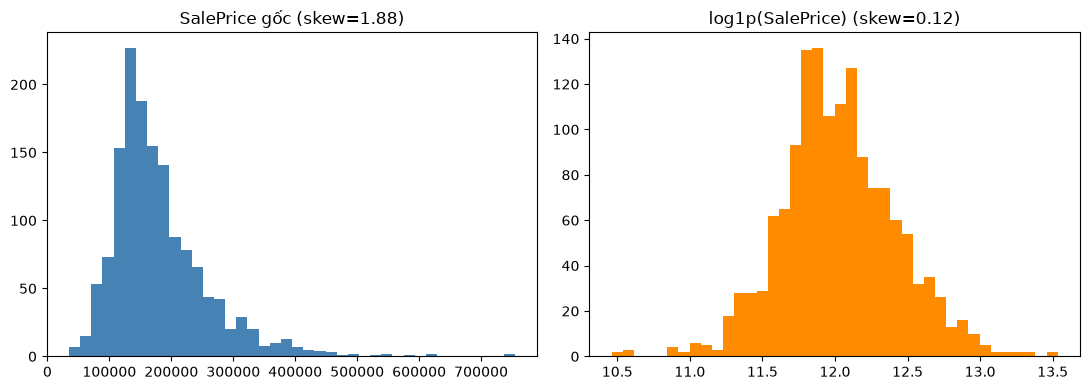

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y_raw, bins=40, color='steelblue')
axes[0].set_title(f'SalePrice gốc (skew={y_raw.skew():.2f})')
axes[1].hist(y_log, bins=40, color='darkorange')
axes[1].set_title(f'log1p(SalePrice) (skew={y_log.skew():.2f})')
plt.tight_layout()
plt.savefig('../reports/missing_analysis.png', dpi=120)
plt.show()

## 5. Lưu kết quả cho notebook tiếp theo

Lưu `X`, `y_log` và `encoder` đã fit để `02_gbr_model.ipynb` dùng lại,
tránh phải chạy lại toàn bộ bước làm sạch.

In [16]:
import os
os.makedirs('../dataset/processed', exist_ok=True)

joblib.dump(X, '../dataset/processed/X_features.joblib')
joblib.dump(y_log, '../dataset/processed/y_log.joblib')
joblib.dump(encoder, '../dataset/processed/encoder.joblib')

print('Đã lưu X, y_log, encoder vào data/processed/')


Đã lưu X, y_log, encoder vào data/processed/
